# Sionna RT Scenario Visualization

This notebook visualizes all scenarios defined in `heatmap_situations.py`, showing:
- Building positions and geometry
- Transmitter location (red)
- RIS points (blue)
- Receiver locations (green)
- Propagation paths (rays) between actors

Each scenario is loaded from its corresponding XML file in `mesh_scene/` and rendered with Sionna RT.

## Setup and Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Import Sionna RT components
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, PathSolver, mi

# Import situation definitions
from heatmap_situations import situations

%matplotlib inline

print("✓ Imports successful")

✓ Imports successful


In [ ]:
def bitmap_to_numpy(bitmap, srgb_gamma: bool = False) -> np.ndarray:
    """
    Convert Sionna/Mitsuba Bitmap object to numpy array for matplotlib display.
    
    Args:
        bitmap: Mitsuba Bitmap object returned by scene.render()
        srgb_gamma: Whether to apply sRGB gamma correction (True for perceived brightness)
    
    Returns:
        numpy array with shape (height, width, 3) and values in range [0.0, 1.0]
    """
    img_converted = bitmap.convert(
        pixel_format=mi.Bitmap.PixelFormat.RGB,
        component_format=mi.Struct.Type.Float32,
        srgb_gamma=srgb_gamma
    )
    return np.array(img_converted)

print("✓ Bitmap conversion utility loaded")

def visualize_scenario(situation, render_resolution=(1200, 900), num_samples=256):
    """
    Visualize a single scenario with buildings, actors, and propagation paths.
    
    Args:
        situation: Situation dictionary from heatmap_situations.py
        render_resolution: Tuple of (width, height) for rendered image
        num_samples: Number of samples for ray tracing (higher = better quality)
    
    Returns:
        numpy array with shape (height, width, 3) suitable for matplotlib display
    """
    simulation_name = situation['simulation_name']
    scene_path = f"mesh_scene/{simulation_name}.xml"
    
    if not os.path.exists(scene_path):
        print(f"❌ Error: Scene file not found: {scene_path}")
        return None
    
    print(f"\n{'='*60}")
    print(f"Visualizing: {simulation_name}")
    print(f"{'='*60}")
    print(f"Scene dimensions: {situation['width']}m × {situation['height']}m")
    print(f"Buildings: {len(situation['buildings'])}")
    print(f"RIS points: {len(situation['ris_points'])}")
    print(f"Receivers: {len(situation['receivers'])}")
    
    # Load scene
    scene = load_scene(scene_path)
    scene.frequency = 3.5e9
    
    # Configure antenna arrays (simple isotropic for visualization)
    scene.tx_array = PlanarArray(
        num_rows=1,
        num_cols=1,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="iso",
        polarization="V"
    )
    
    scene.rx_array = PlanarArray(
        num_rows=1,
        num_cols=1,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="iso",
        polarization="V"
    )
    
    # Add Transmitter (RED)
    tx_point = situation['transmitter']
    tx = Transmitter(
        name="TX",
        position=mi.Point3f([tx_point['x'], tx_point['y'], 1.5]),
        orientation=mi.Point3f([0.0, 0.0, 0.0]),
        display_radius=0.5,
        color=[1.0, 0.0, 0.0]  # Red
    )
    scene.add(tx)
    
    # Add RIS Points (BLUE)
    ris_receivers = []
    for i, ris_point in enumerate(situation['ris_points']):
        ris = Receiver(
            name=f"RIS{i+1}",
            position=mi.Point3f([ris_point['x'], ris_point['y'], 1.5]),
            orientation=mi.Point3f([0.0, 0.0, 0.0]),
            display_radius=0.4,
            color=[0.0, 0.0, 1.0]  # Blue
        )
        scene.add(ris)
        ris_receivers.append(ris)
    
    # Add Receivers (GREEN)
    for i, receiver in enumerate(situation['receivers']):
        rx = Receiver(
            name=f"RX{i+1}",
            position=mi.Point3f([receiver['x'], receiver['y'], 1.5]),
            orientation=mi.Point3f([0.0, 0.0, 0.0]),
            display_radius=0.3,
            color=[0.0, 1.0, 0.0]  # Green
        )
        scene.add(rx)
    
    # Setup camera position (bird's eye view)
    center_x = situation['width'] / 2
    center_y = situation['height'] / 2
    max_dim = max(situation['width'], situation['height'])
    camera_height = max_dim * 0.8  # Adjust height based on scene size
    
    camera = Camera(
        position=mi.Point3f([center_x, center_y, camera_height]),
        look_at=mi.Point3f([center_x, center_y, 0])
    )
    
    # Compute propagation paths
    print("Computing propagation paths...")
    path_solver = PathSolver()
    
    try:
        paths = path_solver(
            scene=scene,
            max_depth=3,
            los=True,
            specular_reflection=True,
            diffuse_reflection=False,
            refraction=True,
            synthetic_array=True,
            seed=42
        )
        
        # Render scene with paths
        print("Rendering scene...")
        img_bitmap = scene.render(
            camera=camera,
            paths=paths,
            resolution=render_resolution,
            num_samples=num_samples,
            clip_at=max(20, max_dim)  # Clip rays at reasonable distance
        )
        
        # Convert Mitsuba Bitmap to numpy array for matplotlib
        img = bitmap_to_numpy(img_bitmap, srgb_gamma=False)
        
        print(f"✓ Visualization complete for {simulation_name}")
        
    except Exception as e:
        print(f"⚠ Warning: Could not compute paths: {e}")
        # Render without paths
        print("Rendering scene without paths...")
        img_bitmap = scene.render(
            camera=camera,
            resolution=render_resolution,
            num_samples=num_samples
        )
        
        # Convert Mitsuba Bitmap to numpy array for matplotlib
        img = bitmap_to_numpy(img_bitmap, srgb_gamma=False)
        
        print(f"✓ Basic visualization complete for {simulation_name}")
    
    # Clean up
    del scene, path_solver
    
    return img

In [2]:
def visualize_scenario(situation, render_resolution=(1200, 900), num_samples=256):
    """
    Visualize a single scenario with buildings, actors, and propagation paths.
    
    Args:
        situation: Situation dictionary from heatmap_situations.py
        render_resolution: Tuple of (width, height) for rendered image
        num_samples: Number of samples for ray tracing (higher = better quality)
    """
    simulation_name = situation['simulation_name']
    scene_path = f"mesh_scene/{simulation_name}.xml"
    
    if not os.path.exists(scene_path):
        print(f"❌ Error: Scene file not found: {scene_path}")
        return
    
    print(f"\n{'='*60}")
    print(f"Visualizing: {simulation_name}")
    print(f"{'='*60}")
    print(f"Scene dimensions: {situation['width']}m × {situation['height']}m")
    print(f"Buildings: {len(situation['buildings'])}")
    print(f"RIS points: {len(situation['ris_points'])}")
    print(f"Receivers: {len(situation['receivers'])}")
    
    # Load scene
    scene = load_scene(scene_path)
    scene.frequency = 3.5e9
    
    # Configure antenna arrays (simple isotropic for visualization)
    scene.tx_array = PlanarArray(
        num_rows=1,
        num_cols=1,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="iso",
        polarization="V"
    )
    
    scene.rx_array = PlanarArray(
        num_rows=1,
        num_cols=1,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="iso",
        polarization="V"
    )
    
    # Add Transmitter (RED)
    tx_point = situation['transmitter']
    tx = Transmitter(
        name="TX",
        position=mi.Point3f([tx_point['x'], tx_point['y'], 1.5]),
        orientation=mi.Point3f([0.0, 0.0, 0.0]),
        display_radius=0.5,
        color=[1.0, 0.0, 0.0]  # Red
    )
    scene.add(tx)
    
    # Add RIS Points (BLUE)
    ris_receivers = []
    for i, ris_point in enumerate(situation['ris_points']):
        ris = Receiver(
            name=f"RIS{i+1}",
            position=mi.Point3f([ris_point['x'], ris_point['y'], 1.5]),
            orientation=mi.Point3f([0.0, 0.0, 0.0]),
            display_radius=0.4,
            color=[0.0, 0.0, 1.0]  # Blue
        )
        scene.add(ris)
        ris_receivers.append(ris)
    
    # Add Receivers (GREEN)
    for i, receiver in enumerate(situation['receivers']):
        rx = Receiver(
            name=f"RX{i+1}",
            position=mi.Point3f([receiver['x'], receiver['y'], 1.5]),
            orientation=mi.Point3f([0.0, 0.0, 0.0]),
            display_radius=0.3,
            color=[0.0, 1.0, 0.0]  # Green
        )
        scene.add(rx)
    
    # Setup camera position (bird's eye view)
    center_x = situation['width'] / 2
    center_y = situation['height'] / 2
    max_dim = max(situation['width'], situation['height'])
    camera_height = max_dim * 0.8  # Adjust height based on scene size
    
    camera = Camera(
        position=mi.Point3f([center_x, center_y, camera_height]),
        look_at=mi.Point3f([center_x, center_y, 0])
    )
    
    # Compute propagation paths
    print("Computing propagation paths...")
    path_solver = PathSolver()
    
    try:
        paths = path_solver(
            scene=scene,
            max_depth=3,
            los=True,
            specular_reflection=True,
            diffuse_reflection=False,
            refraction=True,
            synthetic_array=True,
            seed=42
        )
        
        # Render scene with paths
        print("Rendering scene...")
        img = scene.render(
            camera=camera,
            paths=paths,
            resolution=render_resolution,
            num_samples=num_samples,
            clip_at=max(20, max_dim)  # Clip rays at reasonable distance
        )
        
        print(f"✓ Visualization complete for {simulation_name}")
        
    except Exception as e:
        print(f"⚠ Warning: Could not compute paths: {e}")
        # Render without paths
        print("Rendering scene without paths...")
        img = scene.render(
            camera=camera,
            resolution=render_resolution,
            num_samples=num_samples
        )
        print(f"✓ Basic visualization complete for {simulation_name}")
    
    # Clean up
    del scene, path_solver
    
    return img

# Visualize all scenarios marked with calculate=True
print("="*60)
print("SCENARIO VISUALIZATION")
print("="*60)

scenarios_to_visualize = [s for s in situations if s['calculate']]
print(f"\nFound {len(scenarios_to_visualize)} scenarios to visualize\n")

for i, situation in enumerate(scenarios_to_visualize, 1):
    print(f"\n[{i}/{len(scenarios_to_visualize)}] Processing: {situation['simulation_name']}")
    try:
        img = visualize_scenario(situation, render_resolution=(1200, 900), num_samples=256)
        
        if img is not None:
            plt.figure(figsize=(14, 10))
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"{situation['simulation_name']}\n"
                     f"({situation['width']}m × {situation['height']}m, "
                     f"{len(situation['ris_points'])} RIS, "
                     f"{len(situation['receivers'])} Receivers)",
                     fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
        else:
            print(f"⚠ Skipping visualization (no image generated)")
        
    except Exception as e:
        print(f"❌ Error visualizing {situation['simulation_name']}: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "="*60)
print("✓ Visualization complete!")
print("="*60)

SCENARIO VISUALIZATION

Found 5 scenarios to visualize


[1/5] Processing: Single Reflection

Visualizing: Single Reflection
Scene dimensions: 20m × 20m
Buildings: 2
RIS points: 1
Receivers: 2
Computing propagation paths...
Rendering scene...
✓ Visualization complete for Single Reflection
❌ Error visualizing Single Reflection: Image data of dtype object cannot be converted to float

[2/5] Processing: Single Reflection BIG

Visualizing: Single Reflection BIG
Scene dimensions: 2000m × 2000m
Buildings: 2
RIS points: 1
Receivers: 2
Computing propagation paths...
Rendering scene...


Traceback (most recent call last):
  File "/tmp/ipykernel_254153/2689537233.py", line 14, in <module>
    plt.imshow(img)
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py", line 3601, in imshow
    __ret = gca().imshow(
            ^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/__init__.py", line 1521, in inner
    return func(
           ^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/axes/_axes.py", line 5979, in imshow
    im.set_data(X)
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/image.py", line 685, in set_data
    self._A = self._normalize_image_array(A)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/image.py", line 648, in _normalize_image_array
    raise TypeError(f"Image data of dtype {A.dtype} cannot be "
TypeError: Image data of dtype object cannot be co

✓ Visualization complete for Single Reflection BIG
❌ Error visualizing Single Reflection BIG: Image data of dtype object cannot be converted to float

[3/5] Processing: RISs in series, only final

Visualizing: RISs in series, only final
Scene dimensions: 20m × 20m
Buildings: 2
RIS points: 2
Receivers: 2
Computing propagation paths...


Traceback (most recent call last):
  File "/tmp/ipykernel_254153/2689537233.py", line 14, in <module>
    plt.imshow(img)
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py", line 3601, in imshow
    __ret = gca().imshow(
            ^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/__init__.py", line 1521, in inner
    return func(
           ^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/axes/_axes.py", line 5979, in imshow
    im.set_data(X)
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/image.py", line 685, in set_data
    self._A = self._normalize_image_array(A)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/image.py", line 648, in _normalize_image_array
    raise TypeError(f"Image data of dtype {A.dtype} cannot be "
TypeError: Image data of dtype object cannot be co

Rendering scene...
✓ Visualization complete for RISs in series, only final
❌ Error visualizing RISs in series, only final: Image data of dtype object cannot be converted to float

[4/5] Processing: RISs in series

Visualizing: RISs in series
Scene dimensions: 20m × 20m
Buildings: 5
RIS points: 3
Receivers: 5
Computing propagation paths...


Traceback (most recent call last):
  File "/tmp/ipykernel_254153/2689537233.py", line 14, in <module>
    plt.imshow(img)
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py", line 3601, in imshow
    __ret = gca().imshow(
            ^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/__init__.py", line 1521, in inner
    return func(
           ^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/axes/_axes.py", line 5979, in imshow
    im.set_data(X)
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/image.py", line 685, in set_data
    self._A = self._normalize_image_array(A)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/image.py", line 648, in _normalize_image_array
    raise TypeError(f"Image data of dtype {A.dtype} cannot be "
TypeError: Image data of dtype object cannot be co

Rendering scene...
✓ Visualization complete for RISs in series
❌ Error visualizing RISs in series: Image data of dtype object cannot be converted to float

[5/5] Processing: RISs in parallel

Visualizing: RISs in parallel
Scene dimensions: 20m × 20m
Buildings: 4
RIS points: 5
Receivers: 3
Computing propagation paths...
Rendering scene...


Traceback (most recent call last):
  File "/tmp/ipykernel_254153/2689537233.py", line 14, in <module>
    plt.imshow(img)
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py", line 3601, in imshow
    __ret = gca().imshow(
            ^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/__init__.py", line 1521, in inner
    return func(
           ^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/axes/_axes.py", line 5979, in imshow
    im.set_data(X)
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/image.py", line 685, in set_data
    self._A = self._normalize_image_array(A)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/image.py", line 648, in _normalize_image_array
    raise TypeError(f"Image data of dtype {A.dtype} cannot be "
TypeError: Image data of dtype object cannot be co

✓ Visualization complete for RISs in parallel
❌ Error visualizing RISs in parallel: Image data of dtype object cannot be converted to float

✓ Visualization complete!


Traceback (most recent call last):
  File "/tmp/ipykernel_254153/2689537233.py", line 14, in <module>
    plt.imshow(img)
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py", line 3601, in imshow
    __ret = gca().imshow(
            ^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/__init__.py", line 1521, in inner
    return func(
           ^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/axes/_axes.py", line 5979, in imshow
    im.set_data(X)
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/image.py", line 685, in set_data
    self._A = self._normalize_image_array(A)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/marrocco/pls-ris/.venv/lib/python3.12/site-packages/matplotlib/image.py", line 648, in _normalize_image_array
    raise TypeError(f"Image data of dtype {A.dtype} cannot be "
TypeError: Image data of dtype object cannot be co

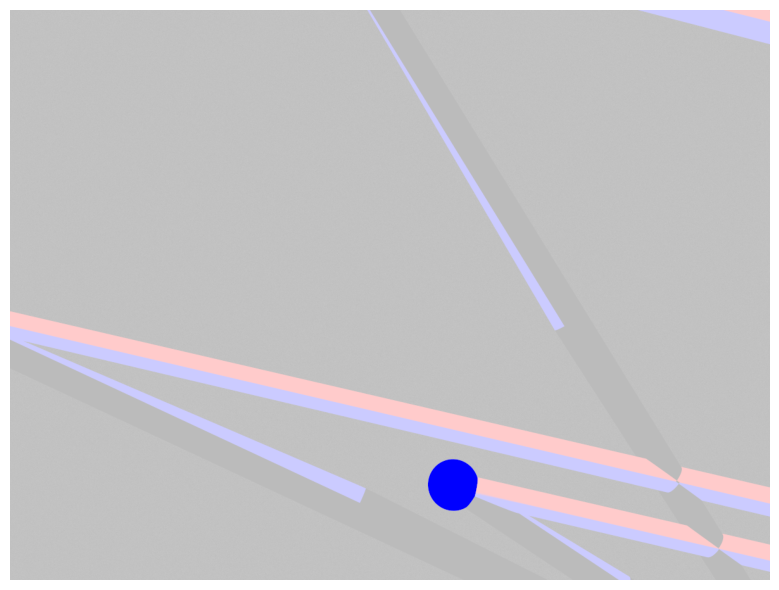

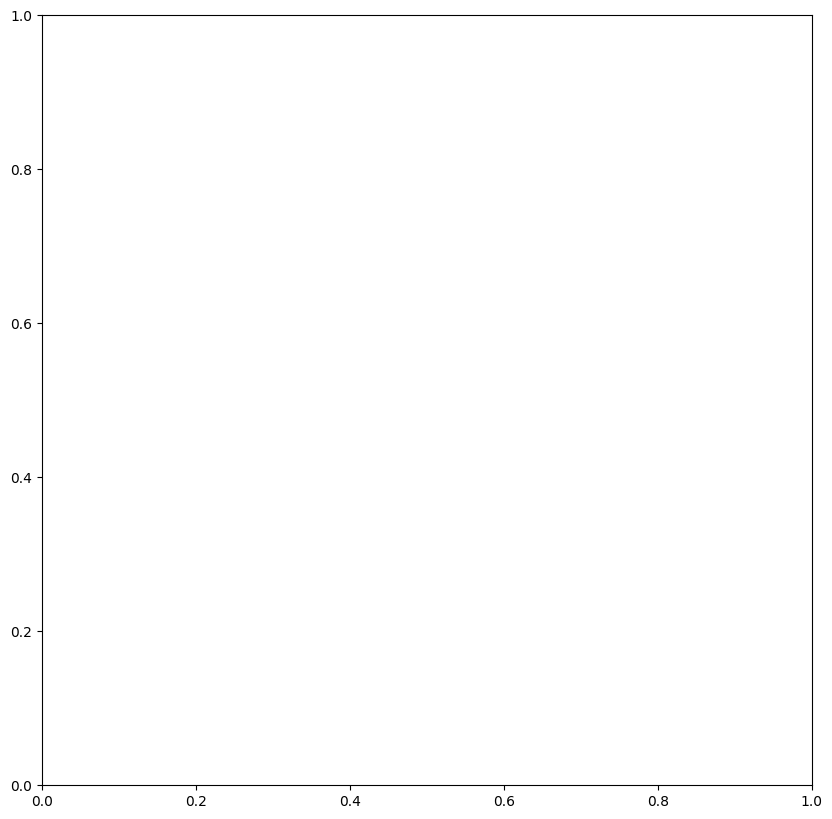

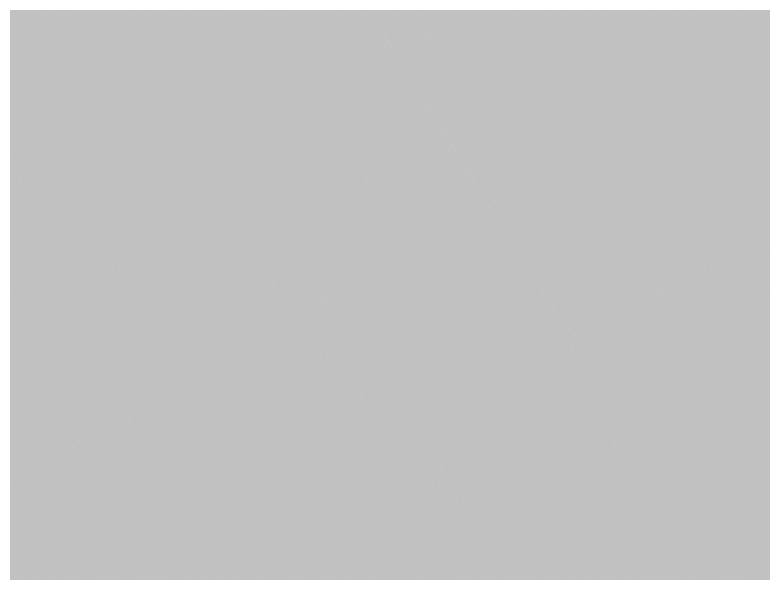

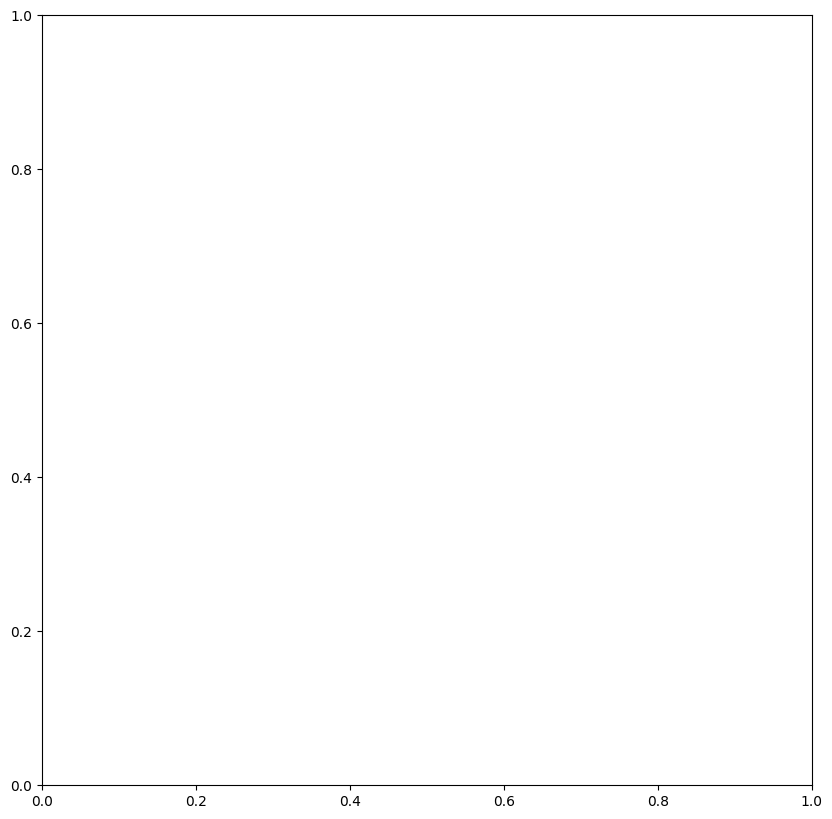

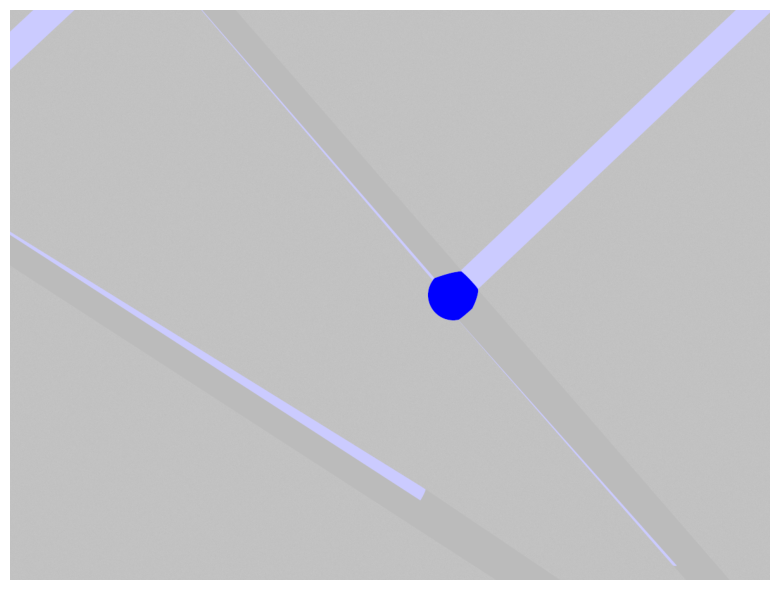

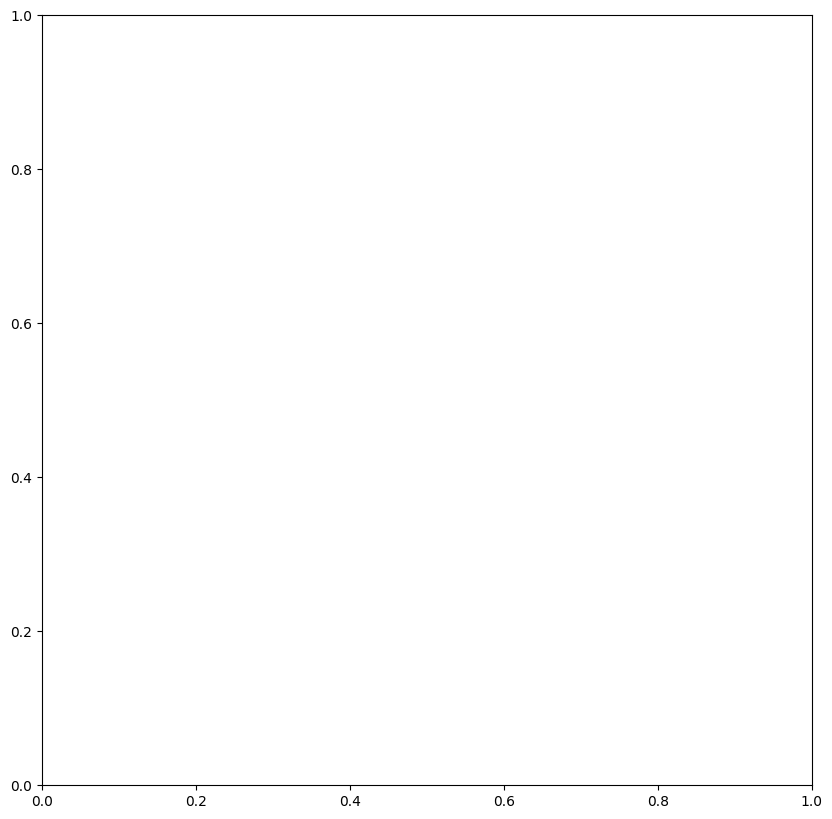

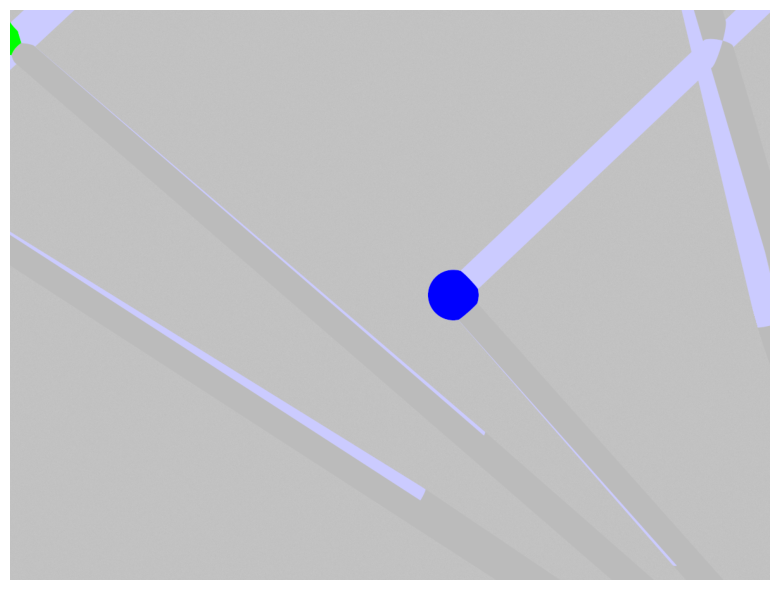

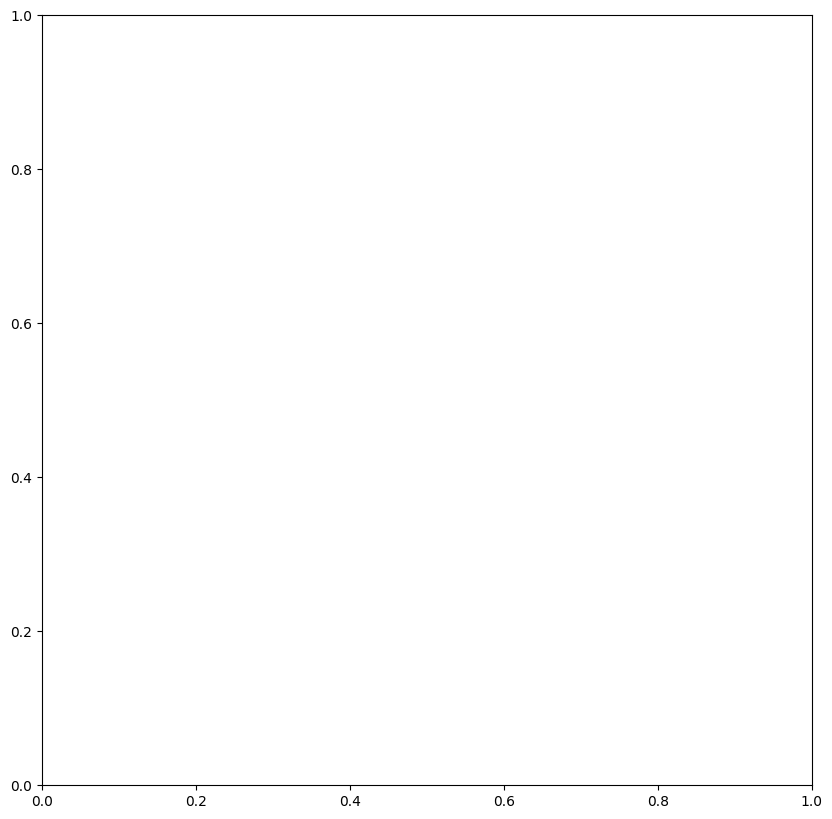

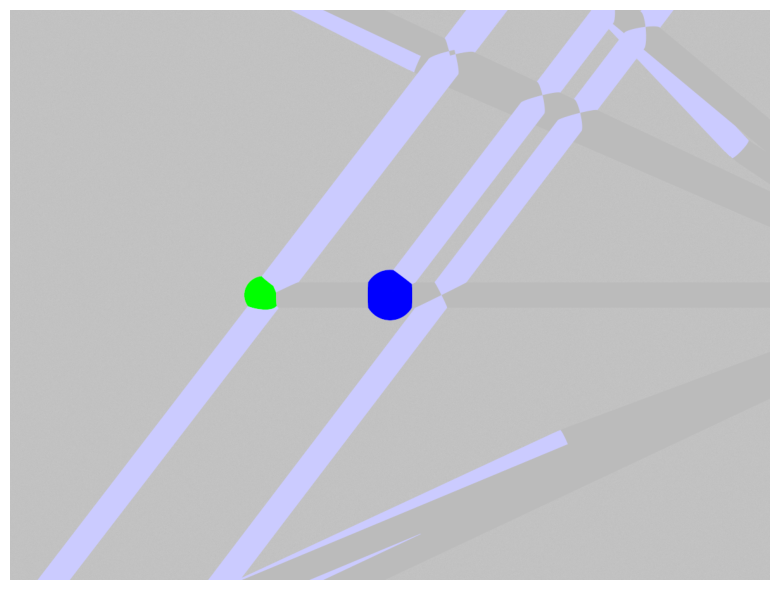

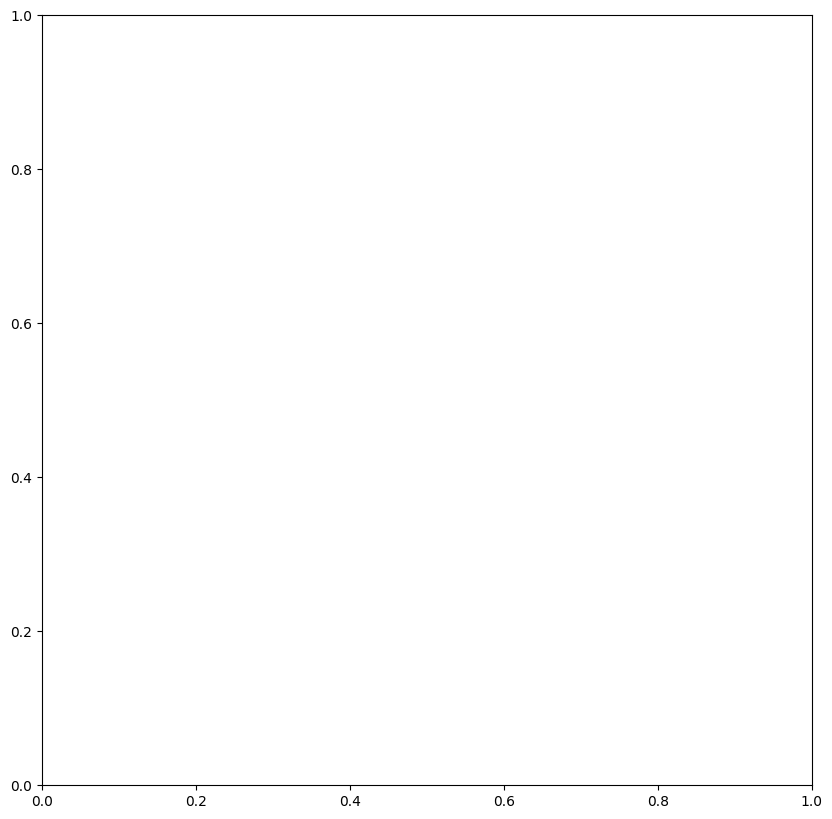

In [3]:
# Visualize all scenarios marked with calculate=True
print("="*60)
print("SCENARIO VISUALIZATION")
print("="*60)

scenarios_to_visualize = [s for s in situations if s['calculate']]
print(f"\nFound {len(scenarios_to_visualize)} scenarios to visualize\n")

for i, situation in enumerate(scenarios_to_visualize, 1):
    print(f"\n[{i}/{len(scenarios_to_visualize)}] Processing: {situation['simulation_name']}")
    try:
        img = visualize_scenario(situation, render_resolution=(1200, 900), num_samples=256)
        plt.figure(figsize=(14, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{situation['simulation_name']}\n"
                 f"({situation['width']}m × {situation['height']}m, "
                 f"{len(situation['ris_points'])} RIS, "
                 f"{len(situation['receivers'])} Receivers)",
                 fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error visualizing {situation['simulation_name']}: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "="*60)
print("✓ Visualization complete!")
print("="*60)

# Visualize a specific scenario by name
scenario_name = "Single Reflection"  # Change this to visualize different scenarios

situation = next((s for s in situations if s['simulation_name'] == scenario_name), None)

if situation:
    img = visualize_scenario(situation, render_resolution=(1400, 1000), num_samples=512)
    
    if img is not None:
        plt.figure(figsize=(16, 12))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{situation['simulation_name']} (High Quality)",
                 fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠ Could not generate visualization for {scenario_name}")
else:
    print(f"Scenario '{scenario_name}' not found.")
    print("Available scenarios:")
    for s in situations:
        print(f"  - {s['simulation_name']}")

In [ ]:
# Visualize a specific scenario by name
scenario_name = "Single Reflection"  # Change this to visualize different scenarios

situation = next((s for s in situations if s['simulation_name'] == scenario_name), None)

if situation:
    img = visualize_scenario(situation, render_resolution=(1400, 1000), num_samples=512)
    plt.figure(figsize=(16, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{situation['simulation_name']} (High Quality)",
             fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"Scenario '{scenario_name}' not found.")
    print("Available scenarios:")
    for s in situations:
        print(f"  - {s['simulation_name']}")

## Scene Information Summary

In [ ]:
# Display summary table of all scenarios
import pandas as pd

summary_data = []
for situation in situations:
    summary_data.append({
        'Scenario': situation['simulation_name'],
        'Calculate': '✓' if situation['calculate'] else '✗',
        'Size (m)': f"{situation['width']}×{situation['height']}",
        'Resolution (m)': situation['resolution'],
        'Buildings': len(situation['buildings']),
        'RIS Points': len(situation['ris_points']),
        'Receivers': len(situation['receivers']),
    })

df = pd.DataFrame(summary_data)
print("\nScenario Summary:")
print("="*80)
display(df)